# Task 3 — Deep Learning Recommendation Model (DLRM)

## Paper Notes

DLRM combines ideas from recommendation systems and deep learning.

### Core Architecture

- **Categorical features:** Each categorical feature is mapped to an embedding vector.
- **Dense features:** Numerical features are processed by a bottom MLP.
- **Feature interactions:** Pairwise dot products are computed between different feature
  representations, including the processed dense representation.
- **Top MLP:** The dense representation and interaction values are concatenated and passed
  through a top MLP.
- **Output:** A sigmoid produces the predicted click probability.

  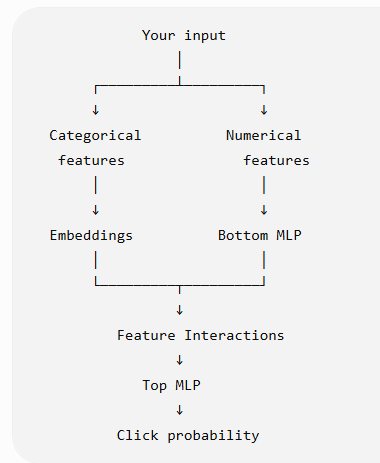

### MLP:-   normal feed-forward neural network made of Dense layers.

### Why DLRM?

DLRM explicitly models second-order interactions between feature representations while
keeping the interaction representation compact. This follows the intuition of
factorization machines, where pairwise interactions are computed using latent vectors.

### DLRM vs Previous Models

- **Matrix Factorization:** Uses latent vectors and their dot product, but is mainly designed
  around user-item interactions.
- **Vanilla Neural CTR:** Uses embeddings and an MLP, allowing nonlinear interactions to be
  learned implicitly.
- **DLRM:** Combines embeddings and neural networks while explicitly computing pairwise
  interactions between feature representations.

### Computational Considerations

Embedding tables can dominate the parameter count and memory usage in recommendation
models. The DLRM paper notes that embeddings can require substantial memory and bandwidth,
while MLP parameters are comparatively smaller but computationally significant.

The paper therefore discusses model parallelism for embedding tables and data parallelism
for MLP computation.

### Dataset Connection

The supplied CTR dataset contains 13 numerical features and 26 categorical features,
matching the feature structure discussed for the Criteo CTR datasets in the DLRM paper.

### Experimental Plan

1. Implement DLRM from scratch using TensorFlow/Keras.
2. Reuse the Task 2 preprocessing and the same train/validation split.
3. Use 32-dimensional embeddings initially.
4. Implement the pairwise dot-product interaction explicitly.
5. Train and evaluate using ROC-AUC, PR-AUC, log loss, and threshold-based F1.
6. Record parameter count, training time, and memory considerations.
7. Run at least one ablation by removing the interaction module.

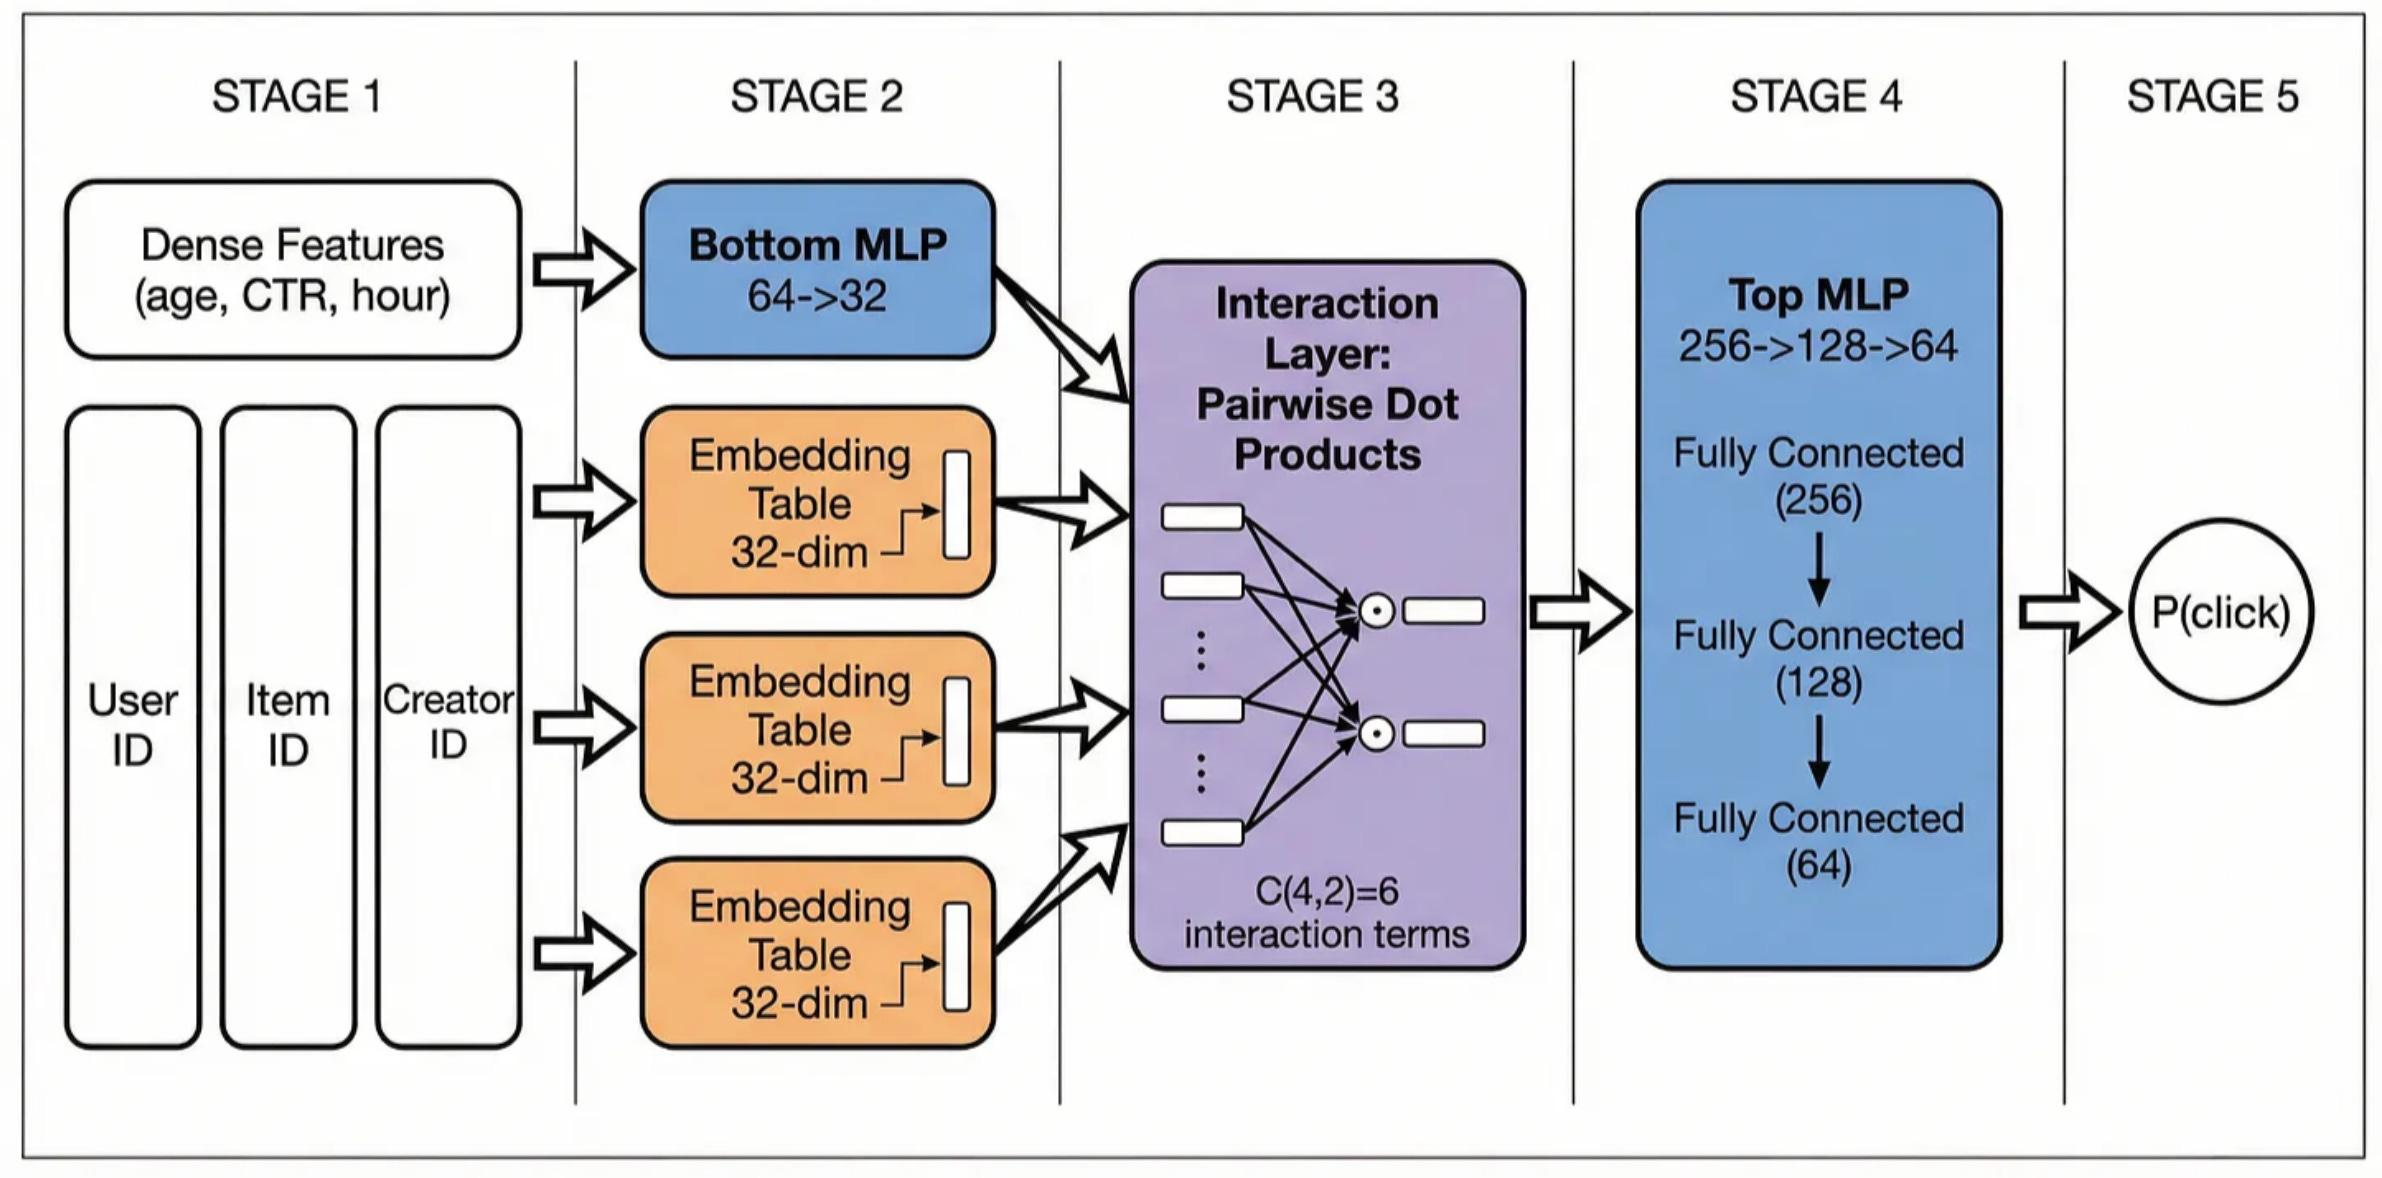

# DLRM Architecture — Stage by Stage

### Stage 1 — Input Features
The dataset contains **13 numerical features** and **26 categorical features**.

### Stage 2 — Feature Representations
- Each categorical feature has its own **32-dimensional embedding table**.
- For one sample, this produces **26 × 32D embedding vectors**.
- The 13 numerical features are passed through a **Bottom MLP (13 → 64 → 32)**, producing one **32D dense representation**.

### Stage 3 — Feature Interactions
We now have **27 total 32D vectors**: 26 categorical embeddings + 1 dense representation.
DLRM computes the **pairwise dot product** between every two different vectors.

\[
\binom{27}{2}=351
\]

Thus, each sample produces **351 interaction values**.

### Stage 4 — Combine and Predict
The original 32D dense representation is retained and concatenated with the 351 interaction values:

\[
351 + 32 = 383
\]

This 383-dimensional vector is passed through the **Top MLP (256 → 128 → 64)**.

### Stage 5 — CTR Prediction
A final sigmoid layer converts the output into the predicted probability of a click:

\[
P(\text{click})
\]


![ChatGPT Image Oct 3, 2026, 03_54_01 PM.png](<attachment:ChatGPT Image Oct 3, 2026, 03_54_01 PM.png>)
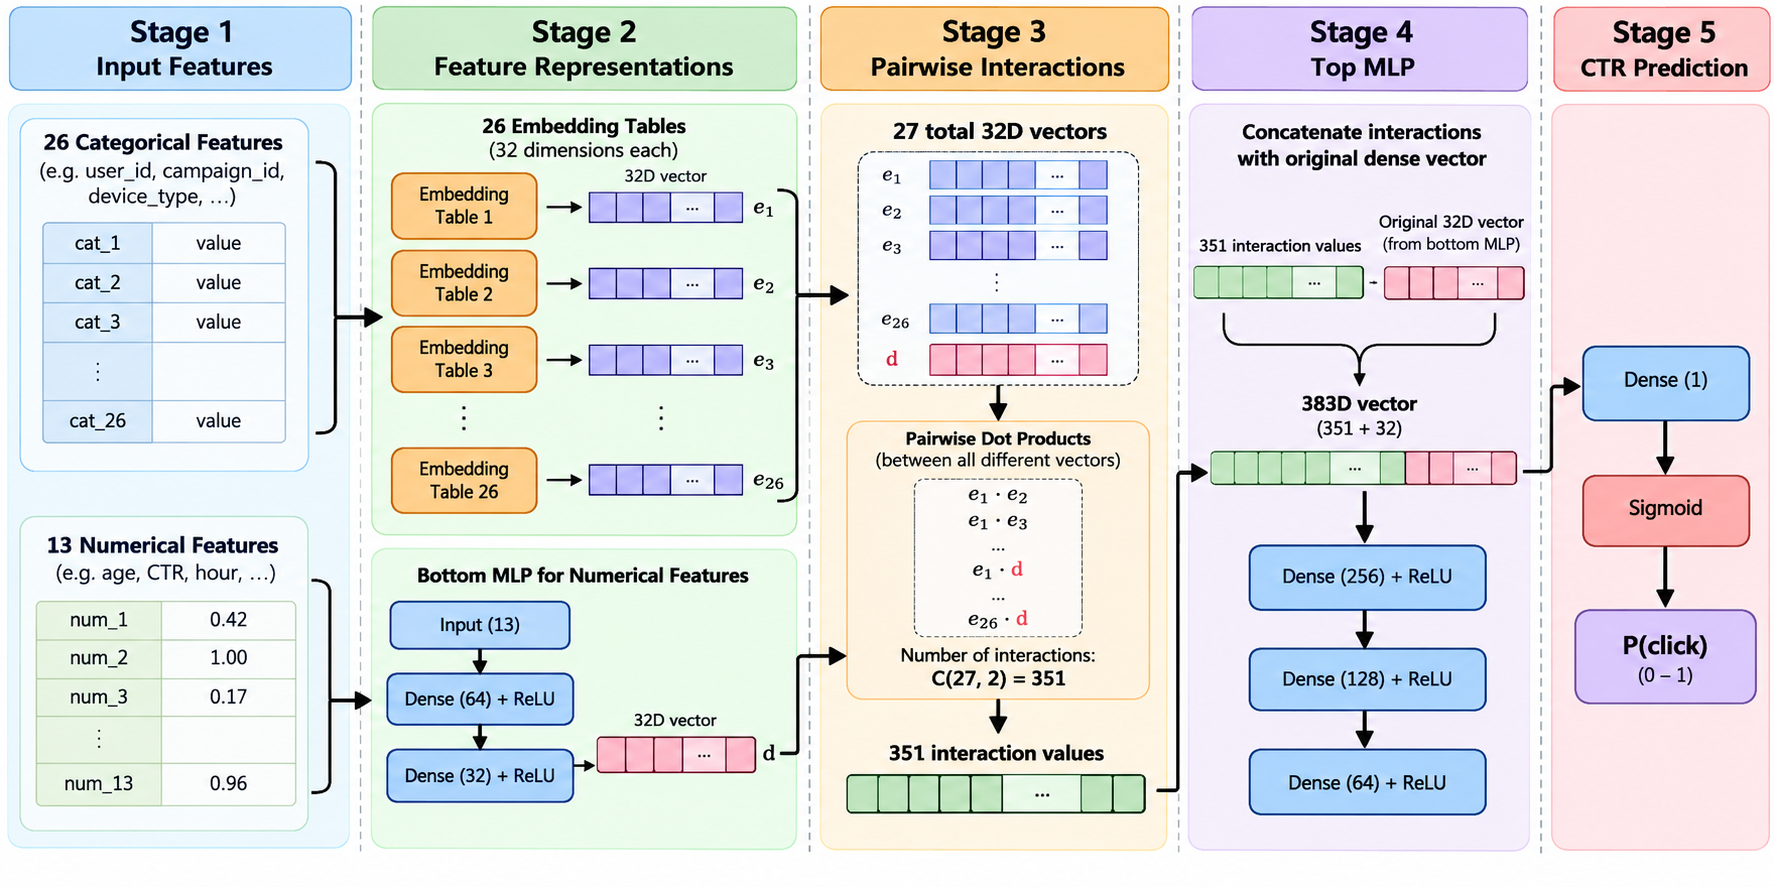

In [1]:
# THIS CELL IS TO MAKE THE NOTEBOOK REPRODUCIBLE

# Set seeds for reproducible neural-network experiments
import os
import random
import numpy as np
import tensorflow as tf

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

tf.config.experimental.enable_op_determinism()

## 1. Data Loading and Preprocessing

In [2]:
# Import libraries and load the CTR dataset
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [3]:
# Load the supplied CTR training and test datasets
train_path = "../../datasets/train.csv"
test_path = "../../datasets/test.csv"

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (40000, 40)
Test shape: (10000, 40)


In [4]:
# Separate target, numerical features, and categorical features
target_col = "label"

numerical_cols = [f"integer_feature_{i}" for i in range(1, 14)]
categorical_cols = [f"categorical_feature_{i}" for i in range(1, 27)]

X = train.drop(columns=target_col)
y = train[target_col]

print("Numerical features:", len(numerical_cols))
print("Categorical features:", len(categorical_cols))

Numerical features: 13
Categorical features: 26


In [5]:
# Create the same stratified train-validation split used in Task 2
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))

Training samples: 32000
Validation samples: 8000


In [6]:
# Preprocess numerical features using training data only
numeric_imputer = SimpleImputer(strategy="median")
numeric_scaler = StandardScaler()

X_train_num = numeric_imputer.fit_transform(X_train[numerical_cols])
X_val_num = numeric_imputer.transform(X_val[numerical_cols])

X_train_num = numeric_scaler.fit_transform(X_train_num)
X_val_num = numeric_scaler.transform(X_val_num)

X_train_num = X_train_num.astype("float32")
X_val_num = X_val_num.astype("float32")

print("Training numerical shape:", X_train_num.shape)
print("Validation numerical shape:", X_val_num.shape)

Training numerical shape: (32000, 13)
Validation numerical shape: (8000, 13)


In [7]:
# Group rare categorical values using training-set frequencies
RARE_THRESHOLD = 5

cat_train_rare = {}
cat_val_rare = {}

for col in categorical_cols:
    counts = X_train[col].value_counts(dropna=False)
    frequent_values = counts[counts >= RARE_THRESHOLD].index

    cat_train_rare[col] = X_train[col].where(
        X_train[col].isin(frequent_values),
        "__RARE__"
    )

    cat_val_rare[col] = X_val[col].where(
        X_val[col].isin(frequent_values),
        "__RARE__"
    )

print("Rare-category handling complete.")

Rare-category handling complete.


In [8]:
# Convert categorical values into training-fitted integer IDs using encoding
cat_train_encoded = {}
cat_val_encoded = {}
embedding_input_dims = {}

for col in categorical_cols:
    values = cat_train_rare[col].astype(str).unique()

    # Reserve ID 0 for any unseen value
    mapping = {value: idx + 1 for idx, value in enumerate(values)}

    cat_train_encoded[col] = (
        cat_train_rare[col]
        .astype(str)
        .map(mapping)
        .fillna(0)
        .astype("int32")
    )

    cat_val_encoded[col] = (
        cat_val_rare[col]
        .astype(str)
        .map(mapping)
        .fillna(0)
        .astype("int32")
    )

    # +1 because ID 0 is reserved for unknown values
    embedding_input_dims[col] = len(mapping) + 1

print("Number of categorical features:", len(cat_train_encoded))
print("Example embedding input dimensions:")
print(list(embedding_input_dims.items())[:5])

Number of categorical features: 26
Example embedding input dimensions:
[('categorical_feature_1', 330), ('categorical_feature_2', 771), ('categorical_feature_3', 1291), ('categorical_feature_4', 238), ('categorical_feature_5', 350)]


In [9]:
# Verify categorical IDs and their ranges
for col in categorical_cols[:3]:
    print(
        col,
        "min =", cat_train_encoded[col].min(),
        "max =", cat_train_encoded[col].max(),
        "embedding input =", embedding_input_dims[col]
    )

categorical_feature_1 min = 1 max = 329 embedding input = 330
categorical_feature_2 min = 1 max = 770 embedding input = 771
categorical_feature_3 min = 1 max = 1290 embedding input = 1291


In [10]:
# Create one 32D embedding table for each categorical feature
# Import Keras layers for building the DLRM
from tensorflow.keras import layers
dlrm_inputs = []
dlrm_embeddings = []

for col in categorical_cols:
    input_layer = layers.Input(
        shape=(1,),
        dtype="int32",
        name=f"dlrm_{col}"
    )

    embedding = layers.Embedding(
        input_dim=embedding_input_dims[col],
        output_dim=32,
        name=f"dlrm_embedding_{col}"
    )(input_layer)

    embedding = layers.Flatten()(embedding)

    dlrm_inputs.append(input_layer)
    dlrm_embeddings.append(embedding)

print("Number of embedding vectors:", len(dlrm_embeddings))
print("Embedding dimension:", dlrm_embeddings[0].shape[-1])

Number of embedding vectors: 26
Embedding dimension: 32


In [11]:
# Create the numerical input for the DLRM
dlrm_numeric_input = layers.Input(
    shape=(13,),
    dtype="float32",
    name="dlrm_numeric_input"
)

print("Numerical input dimension:", dlrm_numeric_input.shape[-1])

Numerical input dimension: 13


In [12]:
# Transform numerical features into a 32D dense representation
dlrm_dense = layers.Dense(
    64,
    activation="relu",
    name="dlrm_bottom_dense_64"
)(dlrm_numeric_input)

dlrm_dense = layers.Dense(
    32,
    activation="relu",
    name="dlrm_bottom_dense_32"
)(dlrm_dense)

print("Bottom MLP output dimension:", dlrm_dense.shape[-1])

Bottom MLP output dimension: 32


In [13]:
# Implement DLRM pairwise dot-product interactions
class PairwiseDotInteraction(layers.Layer):
    def __init__(self, num_vectors, **kwargs):
        super().__init__(**kwargs)

        self.num_vectors = num_vectors

        pairs = [
            (i, j)
            for i in range(num_vectors)
            for j in range(i + 1, num_vectors)
        ]

        self.pair_i = tf.constant(
            [pair[0] for pair in pairs],
            dtype=tf.int32
        )

        self.pair_j = tf.constant(
            [pair[1] for pair in pairs],
            dtype=tf.int32
        )

    def call(self, inputs):
        # Stack feature vectors into (batch, 27, 32)
        x = tf.stack(inputs, axis=1)

        # Select the two vectors for every pair
        x_i = tf.gather(x, self.pair_i, axis=1)
        x_j = tf.gather(x, self.pair_j, axis=1)

        # Dot product for every pair
        interactions = tf.reduce_sum(x_i * x_j, axis=-1)

        return interactions

In [14]:
# Compute all 351 pairwise interactions
all_dlrm_vectors = dlrm_embeddings + [dlrm_dense]

dlrm_interactions = PairwiseDotInteraction(
    num_vectors=27,
    name="dlrm_interactions"
)(all_dlrm_vectors)

print("Number of feature vectors:", len(all_dlrm_vectors))
print("Number of interactions:", dlrm_interactions.shape[-1])


Number of feature vectors: 27
Number of interactions: 351


In [15]:
# Combine interaction values with the original dense representation
dlrm_combined = layers.Concatenate(
    name="dlrm_combined"
)([dlrm_interactions, dlrm_dense])

print("Combined DLRM representation:", dlrm_combined.shape[-1])

Combined DLRM representation: 383


In [16]:
# Build the top MLP and final CTR prediction layer
dlrm_top = layers.Dense(
    256,
    activation="relu",
    name="dlrm_top_dense_256"
)(dlrm_combined)

dlrm_top = layers.Dense(
    128,
    activation="relu",
    name="dlrm_top_dense_128"
)(dlrm_top)

dlrm_top = layers.Dense(
    64,
    activation="relu",
    name="dlrm_top_dense_64"
)(dlrm_top)

dlrm_output = layers.Dense(
    1,
    activation="sigmoid",
    name="dlrm_output"
)(dlrm_top)

print("DLRM output shape:", dlrm_output.shape)

DLRM output shape: (None, 1)


In [17]:
# Assemble the complete DLRM model
dlrm_model = tf.keras.Model(
    inputs=dlrm_inputs + [dlrm_numeric_input],
    outputs=dlrm_output,
    name="DLRM"
)

print("Total parameters:", f"{dlrm_model.count_params():,}")

Total parameters: 459,937


In [18]:
# Compile the DLRM with binary cross-entropy and CTR metrics
dlrm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.AUC(name="roc_auc"),
        tf.keras.metrics.AUC(
            name="pr_auc",
            curve="PR"
        ),
        tf.keras.metrics.BinaryAccuracy(name="accuracy")
    ]
)

print("DLRM model compiled successfully.")

DLRM model compiled successfully.


In [19]:
# Display the complete DLRM architecture
dlrm_model.summary()

Model: "DLRM"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ dlrm_categorical_f… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dlrm_categorical_f… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dlrm_categorical_f… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dlrm_categorical_f… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dlrm_categorical_f… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dlrm_categorical_f… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dlrm_categorical_f… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dlrm_categorical_f… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dlrm_categorical_f… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dlrm_categorical_f… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dlrm_categorical_f… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dlrm_categorical_f… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dlrm_categorical_f… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dlrm_categorical_f… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dlrm_categorical_f… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dlrm_categorical_f… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dlrm_categorical_f… │ (None, 1)         │          0 │ -               

 Total params: 459,937 (1.75 MB)

 Trainable params: 459,937 (1.75 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
# Prepare categorical and numerical arrays for DLRM training
dlrm_train_inputs = {
    f"dlrm_{col}": cat_train_encoded[col].values
    for col in categorical_cols
}

dlrm_train_inputs["dlrm_numeric_input"] = X_train_num

dlrm_val_inputs = {
    f"dlrm_{col}": cat_val_encoded[col].values
    for col in categorical_cols
}

dlrm_val_inputs["dlrm_numeric_input"] = X_val_num

print("Number of model inputs:", len(dlrm_train_inputs))
print("Training numerical shape:", dlrm_train_inputs["dlrm_numeric_input"].shape)

Number of model inputs: 27
Training numerical shape: (32000, 13)


In [21]:
# Train the DLRM and measure wall-clock training time
import time

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_pr_auc",
    mode="max",
    patience=2,
    restore_best_weights=True
)

start_time = time.perf_counter()

dlrm_history = dlrm_model.fit(
    dlrm_train_inputs,
    y_train,
    validation_data=(dlrm_val_inputs, y_val),
    epochs=10,
    batch_size=256,
    callbacks=[early_stopping],
    verbose=1
)

training_time = time.perf_counter() - start_time

print(f"Training time: {training_time:.2f} seconds")

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.9661 - loss: 0.2323 - pr_auc: 0.0328 - roc_auc: 0.5177 - val_accuracy: 0.9680 - val_loss: 0.1393 - val_pr_auc: 0.0575 - val_roc_auc: 0.6451
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9680 - loss: 0.1348 - pr_auc: 0.0743 - roc_auc: 0.6950 - val_accuracy: 0.9680 - val_loss: 0.1326 - val_pr_auc: 0.0771 - val_roc_auc: 0.7077
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9680 - loss: 0.1164 - pr_auc: 0.1624 - roc_auc: 0.8415 - val_accuracy: 0.9680 - val_loss: 0.1400 - val_pr_auc: 0.0741 - val_roc_auc: 0.6877
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9680 - loss: 0.0980 - pr_auc: 0.2842 - roc_auc: 0.9127 - val_accuracy: 0.9679 - val_loss: 0.1625 - val_pr_auc: 0.0618 - val_roc_auc: 0.6540
Training time: 16.04 seconds


In [22]:
# Evaluate the restored DLRM on the validation set
dlrm_val_results = dlrm_model.evaluate(
    dlrm_val_inputs,
    y_val,
    verbose=0,
    return_dict=True
)

print("DLRM validation results:")
for metric, value in dlrm_val_results.items():
    print(f"{metric}: {value:.4f}")

DLRM validation results:
accuracy: 0.9680
loss: 0.1326
pr_auc: 0.0771
roc_auc: 0.7077


In [23]:
# Generate validation click probabilities
dlrm_val_pred = dlrm_model.predict(
    dlrm_val_inputs,
    batch_size=256,
    verbose=0
).ravel()

print("Prediction range:", dlrm_val_pred.min(), "to", dlrm_val_pred.max())

Prediction range: 6.9022677e-16 to 0.26082912


In [24]:
# Find the validation threshold with the best F1 score
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.01, 0.51, 0.01)

threshold_results = []

for threshold in thresholds:
    pred_labels = (dlrm_val_pred >= threshold).astype(int)

    precision = precision_score(
        y_val,
        pred_labels,
        zero_division=0
    )

    recall = recall_score(
        y_val,
        pred_labels,
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        pred_labels,
        zero_division=0
    )

    threshold_results.append(
        (threshold, precision, recall, f1)
    )

best_threshold, best_precision, best_recall, best_f1 = max(
    threshold_results,
    key=lambda x: x[3]
)

print(f"Best threshold: {best_threshold:.2f}")
print(f"Precision: {best_precision:.4f}")
print(f"Recall: {best_recall:.4f}")
print(f"F1: {best_f1:.4f}")

Best threshold: 0.08
Precision: 0.1151
Recall: 0.2656
F1: 0.1606


## Ablation -- Remove DLRM's explicit pairwise interaction mechanism.

ablation = controlled removal/change of a model component to understand its contribution.

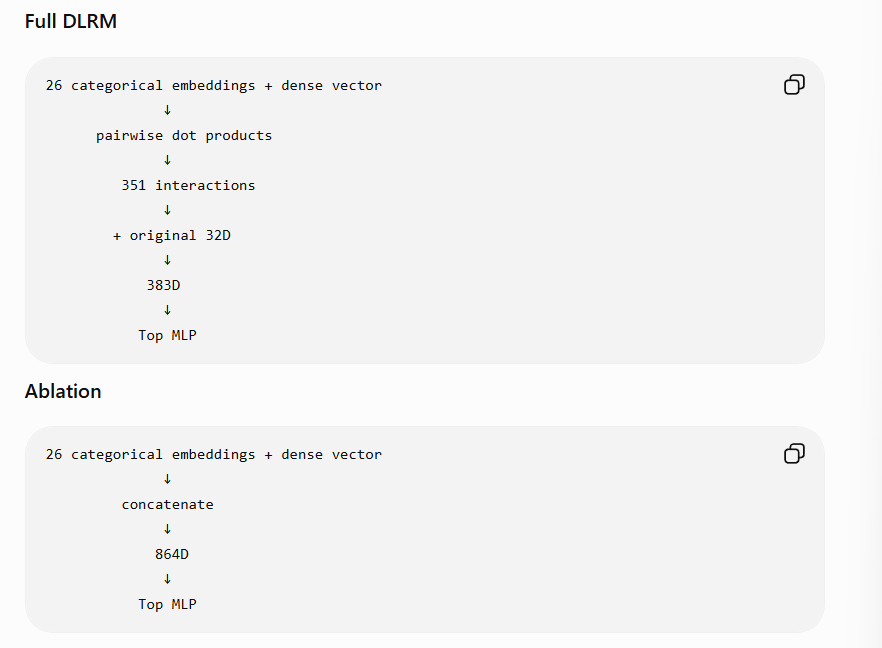

Does explicitly computing pairwise feature interactions improve CTR prediction compared with simply giving the neural network all feature representations?

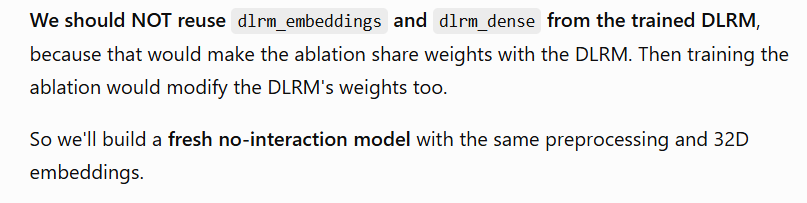

In [25]:
# Build a fresh DLRM ablation without explicit interactions
ablation_inputs = []
ablation_embeddings = []

for col in categorical_cols:
    input_layer = layers.Input(
        shape=(1,),
        dtype="int32",
        name=f"ablation_{col}"
    )

    embedding = layers.Embedding(
        input_dim=embedding_input_dims[col],
        output_dim=32,
        name=f"ablation_embedding_{col}"
    )(input_layer)

    embedding = layers.Flatten()(embedding)

    ablation_inputs.append(input_layer)
    ablation_embeddings.append(embedding)

ablation_numeric_input = layers.Input(
    shape=(13,),
    dtype="float32",
    name="ablation_numeric_input"
)

ablation_inputs.append(ablation_numeric_input)

# Build a fresh bottom MLP for numerical features
ablation_dense = layers.Dense(
    64,
    activation="relu",
    name="ablation_bottom_dense_64"
)(ablation_numeric_input)

ablation_dense = layers.Dense(
    32,
    activation="relu",
    name="ablation_bottom_dense_32"
)(ablation_dense)

# Concatenate all representations without pairwise interactions
ablation_combined = layers.Concatenate(
    name="ablation_combined"
)(ablation_embeddings + [ablation_dense])

print("Ablation representation:", ablation_combined.shape[-1])

Ablation representation: 864


In [26]:
# Build the ablation top MLP and output layer
ablation_top = layers.Dense(
    256,
    activation="relu",
    name="ablation_top_dense_256"
)(ablation_combined)

ablation_top = layers.Dense(
    128,
    activation="relu",
    name="ablation_top_dense_128"
)(ablation_top)

ablation_top = layers.Dense(
    64,
    activation="relu",
    name="ablation_top_dense_64"
)(ablation_top)

ablation_output = layers.Dense(
    1,
    activation="sigmoid",
    name="ablation_output"
)(ablation_top)

dlrm_ablation = tf.keras.Model(
    inputs=ablation_inputs,
    outputs=ablation_output,
    name="DLRM_No_Interaction"
)

print("Ablation parameters:", f"{dlrm_ablation.count_params():,}")

Ablation parameters: 583,073


In [27]:
# Compile the no-interaction ablation with the same training setup
dlrm_ablation.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.AUC(name="roc_auc"),
        tf.keras.metrics.AUC(
            name="pr_auc",
            curve="PR"
        ),
        tf.keras.metrics.BinaryAccuracy(name="accuracy")
    ]
)

print("Ablation model compiled successfully.")

Ablation model compiled successfully.


In [28]:
# Prepare training and validation inputs for the ablation
ablation_train_inputs = {
    f"ablation_{col}": cat_train_encoded[col].values
    for col in categorical_cols
}

ablation_train_inputs["ablation_numeric_input"] = X_train_num

ablation_val_inputs = {
    f"ablation_{col}": cat_val_encoded[col].values
    for col in categorical_cols
}

ablation_val_inputs["ablation_numeric_input"] = X_val_num

print("Number of ablation inputs:", len(ablation_train_inputs))

Number of ablation inputs: 27


In [29]:
# Train the no-interaction ablation and measure training time
start_time = time.perf_counter()

ablation_early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_pr_auc",
    mode="max",
    patience=2,
    restore_best_weights=True
)

ablation_history = dlrm_ablation.fit(
    ablation_train_inputs,
    y_train,
    validation_data=(ablation_val_inputs, y_val),
    epochs=10,
    batch_size=256,
    callbacks=[ablation_early_stopping],
    verbose=1
)

ablation_training_time = time.perf_counter() - start_time

print(f"Ablation training time: {ablation_training_time:.2f} seconds")

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9650 - loss: 0.2086 - pr_auc: 0.0327 - roc_auc: 0.5153 - val_accuracy: 0.9680 - val_loss: 0.1380 - val_pr_auc: 0.0557 - val_roc_auc: 0.6419
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9680 - loss: 0.1347 - pr_auc: 0.0730 - roc_auc: 0.6853 - val_accuracy: 0.9680 - val_loss: 0.1328 - val_pr_auc: 0.0905 - val_roc_auc: 0.7106
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9680 - loss: 0.1227 - pr_auc: 0.1293 - roc_auc: 0.8053 - val_accuracy: 0.9680 - val_loss: 0.1347 - val_pr_auc: 0.0837 - val_roc_auc: 0.6929
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9680 - loss: 0.1089 - pr_auc: 0.2053 - roc_auc: 0.8752 - val_accuracy: 0.9680 - val_loss: 0.1489 - val_pr_auc: 0.0703 - val_roc_auc: 0.6585
Ablation training time: 9.87 seconds


In [30]:
# Evaluate the restored no-interaction ablation
ablation_val_results = dlrm_ablation.evaluate(
    ablation_val_inputs,
    y_val,
    verbose=0,
    return_dict=True
)

print("Ablation validation results:")

for metric, value in ablation_val_results.items():
    print(f"{metric}: {value:.4f}")

Ablation validation results:
accuracy: 0.9680
loss: 0.1328
pr_auc: 0.0905
roc_auc: 0.7106


In [31]:
# Generate validation probabilities for the ablation
ablation_val_pred = dlrm_ablation.predict(
    ablation_val_inputs,
    batch_size=256,
    verbose=0
).ravel()

print(
    "Prediction range:",
    ablation_val_pred.min(),
    "to",
    ablation_val_pred.max()
)

Prediction range: 5.91022e-09 to 0.1839112


In [32]:
# Find the best F1 threshold for the ablation
thresholds = np.arange(0.01, 0.51, 0.01)

ablation_threshold_results = []

for threshold in thresholds:
    pred_labels = (ablation_val_pred >= threshold).astype(int)

    precision = precision_score(
        y_val,
        pred_labels,
        zero_division=0
    )

    recall = recall_score(
        y_val,
        pred_labels,
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        pred_labels,
        zero_division=0
    )

    ablation_threshold_results.append(
        (threshold, precision, recall, f1)
    )

(
    ablation_best_threshold,
    ablation_best_precision,
    ablation_best_recall,
    ablation_best_f1
) = max(
    ablation_threshold_results,
    key=lambda x: x[3]
)

print(f"Best threshold: {ablation_best_threshold:.2f}")
print(f"Precision: {ablation_best_precision:.4f}")
print(f"Recall: {ablation_best_recall:.4f}")
print(f"F1: {ablation_best_f1:.4f}")

Best threshold: 0.06
Precision: 0.0957
Recall: 0.3359
F1: 0.1489


## Ablation — Removing Explicit Feature Interactions

The DLRM interaction layer was removed while keeping the categorical embeddings,
bottom MLP, optimizer, training split, and top MLP setup comparable.

The ablation directly concatenates the 26 categorical embedding vectors and the
32-dimensional dense representation, giving:

- 26 × 32 = 832 categorical representation values
- 32 dense representation values
- Total = 864 dimensions

These are passed to the top MLP (256 → 128 → 64).

| Metric | DLRM | No-Interaction Ablation |
|---|---:|---:|
| ROC-AUC | 0.7077 | 0.7106 |
| PR-AUC | 0.0771 | 0.0905 |
| Log Loss | 0.1326 | 0.1328 |
| Precision | 0.1151 | 0.0957 |
| Recall | 0.2656 | 0.3359 |
| F1 | 0.1606 | 0.1489 |
| Best Threshold | 0.08 | 0.06 |
| Parameters | 459,937 | 583,073 |
| Training Time | 16.04 s | 10.50 s |

### Interpretation

On this validation split, the no-interaction model achieved slightly higher
ROC-AUC and substantially higher PR-AUC, while the DLRM achieved slightly
lower log loss and higher precision and F1.

The ablation also achieved higher recall, indicating that its predictions
identified more positive examples at its selected threshold, but this came
with lower precision.

Overall, the explicit pairwise interaction mechanism did not provide a clear
validation advantage in this experiment. The differences are relatively
small and should not be interpreted as showing that DLRM interactions are
universally ineffective; performance can depend on the dataset, preprocessing,
architecture, and training setup.

The ablation also has more parameters because it feeds the full
864-dimensional representation into the top MLP, whereas DLRM reduces the
representations to 351 interaction values plus the 32-dimensional dense
representation.

## Parameter Count and Memory Considerations

The DLRM contains **459,937 trainable parameters**, while the
no-interaction ablation contains **583,073 parameters**.

For FP32 weights:

**Memory = parameters × 4 bytes**

Therefore:

- **DLRM:** 459,937 × 4 ≈ **1.75 MiB**
- **Ablation:** 583,073 × 4 ≈ **2.22 MiB**

The DLRM has fewer parameters because the pairwise interaction stage compresses
the 27 feature vectors into **351 scalar interaction values** before the top MLP.

The embedding tables account for a substantial portion of the DLRM parameters.
This is important for recommendation models because increasing categorical
cardinality increases the size of the embedding tables and therefore the
model's memory requirements.

The reported memory values represent **FP32 model weights only**. Actual
training memory is higher because it also includes optimizer states,
activations, gradients, and framework overhead.

### Training Cost

| Model | Parameters | Training Time |
|---|---:|---:|
| DLRM | 459,937 | 16.04 s |
| No-Interaction Ablation | 583,073 | 10.50 s |

The DLRM required more training time in this experiment despite having fewer
parameters, reflecting the additional computation introduced by the explicit
pairwise interaction stage.

# Task 3 — Final Results and Comparison

## DLRM vs Neural CTR Models

The DLRM was evaluated using the same train/validation split and the same
evaluation metrics used in the Neural CTR experiments.

| Model | ROC-AUC | PR-AUC | Log Loss | Precision | Recall | F1 |
|---|---:|---:|---:|---:|---:|---:|
| Task 2 Baseline NN | 0.7168 | 0.0910 | 0.1322 | 0.0958 | 0.3438 | 0.1498 |
| Task 2 Exp 4 | 0.7203 | 0.0852 | 0.1321 | 0.1166 | 0.2969 | **0.1674** |
| DLRM | 0.7077 | 0.0771 | 0.1326 | 0.1151 | 0.2656 | 0.1606 |
| DLRM Ablation | **0.7106** | **0.0905** | **0.1328** | 0.0957 | **0.3359** | 0.1489 |

The DLRM did not outperform the Task 2 models on this validation split.

Compared with the DLRM, the no-interaction ablation achieved slightly higher
ROC-AUC and substantially higher PR-AUC, while the DLRM achieved slightly
lower log loss, higher precision, and higher F1.

However, these results are specific to this dataset, preprocessing, model
configuration, and single validation split. They should not be interpreted as
a general ranking of the architectures.

## DLRM vs Matrix Factorization

Matrix Factorization and DLRM both use learned latent representations, but
their recommendation settings are different.

**Matrix Factorization:**

- Learns a latent vector for each user and item.
- Uses their interaction, typically a dot product, to estimate preference.
- Captures a direct user-item affinity.

**DLRM:**

- Uses separate embeddings for multiple categorical features.
- Processes numerical features with a Bottom MLP.
- Explicitly computes pairwise interactions between the resulting feature
  representations.
- Uses a Top MLP to predict click probability.

Therefore, the numerical metrics from Task 1 and Task 3 should not be compared
directly because they use different datasets and prediction objectives:
Task 1 predicts movie ratings, while Task 3 predicts binary clicks.

## DLRM vs Vanilla Neural Network

The main architectural difference is how feature interactions are handled.

**Vanilla Neural Network:**

Categorical embeddings + numerical features → MLP → prediction

The MLP learns useful interactions implicitly.

**DLRM:**

Categorical embeddings + numerical representation

→ explicit pairwise interactions

→ Top MLP

→ prediction

DLRM therefore introduces a structured second-order interaction mechanism
instead of relying entirely on the MLP to discover interactions.

In this experiment, the explicit interactions did not produce a clear
validation improvement, but they demonstrate the core architectural idea of
DLRM.

# Recommendation Behavior and Model Complexity

## How the Models Represent Recommendation Behavior

### Matrix Factorization

Matrix Factorization represents each user and item using a learned latent
vector. Their interaction estimates how well the user's latent preferences
match the item's latent characteristics.

This provides a compact representation of user-item affinity, but the model
is primarily designed around the user-item relationship.

### Vanilla Neural CTR Model

The Neural CTR model extends this idea by representing multiple categorical
features with embeddings and combining them with numerical features.

A multilayer perceptron then learns nonlinear relationships between these
representations.

This makes the model more flexible than simple Matrix Factorization, but the
feature interactions are learned implicitly by the dense layers.

### DLRM

DLRM makes feature interactions explicit.

For each sample, the model produces:

- 26 categorical embedding vectors
- 1 numerical representation from the Bottom MLP
- 27 total feature vectors
- 351 pairwise interactions

The interaction values are then combined with the original numerical
representation and processed by the Top MLP.

This structure is particularly suited to recommendation problems where
interactions between categorical fields can be important.

## Complexity Trade-off

The three approaches represent different trade-offs:

| Model | Main Representation | Interaction Mechanism | Complexity |
|---|---|---|---|
| Matrix Factorization | User + item latent vectors | Direct dot product | Low |
| Vanilla Neural CTR | Embeddings + numerical features | Learned implicitly by MLP | Moderate |
| DLRM | Embeddings + numerical representation | Explicit pairwise dot products + MLP | Higher |

DLRM introduces additional computation because the model explicitly constructs
pairwise interactions between feature representations.

With 27 vectors, the number of pairwise interactions is:

**27 × 26 / 2 = 351**

This gives the model a structured way to represent second-order feature
interactions, but also introduces additional computation compared with a
simple MLP.

## Overall Findings

The experiments demonstrate that increasing architectural complexity does
not automatically improve validation performance.

For this dataset:

- The Task 2 Neural CTR models achieved ROC-AUC values around **0.70–0.72**.
- The DLRM achieved **0.7077 ROC-AUC** and **0.0771 PR-AUC**.
- Removing the explicit interaction layer produced **0.7106 ROC-AUC** and
  **0.0905 PR-AUC** in the ablation.
- The DLRM required **16.04 s** of training time compared with **10.50 s**
  for the no-interaction ablation.

The experiments therefore show both the motivation for explicit feature
interactions and the importance of validating whether those interactions
actually improve the target task.

The DLRM implementation successfully reproduces the core architecture:
embedding tables for sparse features, a Bottom MLP for dense features,
explicit pairwise interactions, and a Top MLP for binary prediction.